In [21]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference
from fractal_SG_solver_new import d2_fractal_L_W2 
from fractal_SG_solver_new import ddphi, H5_dd, pointwise_fractal
from alpha_fractal_function import alpha_fractalize,alpha_fractalize_second_derivative

In [22]:
# Paper Example 1 parameters.
a = -1.0
b = 1.0
#######################
K = 8
S =[0.4,0.5,0.6,0.8]
c = 0.027 
################
h = 0.01
tau = 0.01
################
T = 1

n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
Nt = int(round(T / tau))

x = np.linspace(a, b, n + 1)

# Interpolation center indices k_j, j = 1,...,N
k_idx = np.concatenate(([1], K * np.arange(1, N - 1), [n - 1])).astype(int)

xk = x[k_idx]
xkj = []
for j in range(1, N+1):
    if j == 1:
        value = float(x[1])
        xkj.append(value)

    elif 1 < j < N:
        value = a + ((j - 1) * (b - a)) / N
        xkj.append(value)
    elif j == N:
        value = float(x[n - 1])
        xkj.append(value)

In [23]:
def f(x):
    y = np.sin(np.pi * x)
    return np.where(np.isclose(y, 0.0, atol=1e-12), 0.0, y)

# Even base function
# def g(x):
#     return (x**2 - x**4)/(np.exp(x) + 2)

# Odd base function
def g(x):
    return x * (1 - x**2)


f_beta = [ 0.005, 0.0025, 0.0025, 0.005]
n_subintervals = len(f_beta)
n_iter = 6
X = np.linspace(a, b, n_subintervals + 1)
sine_pi_fractal = alpha_fractalize(f, g, -1, 1, n_subintervals, f_beta, n_iter)



def odd_dirichlet_extension(z):
    y = ((z + 1) % 4) - 1   # maps to [-1, 3)

    if y <= 1:
        return pointwise_fractal(y, sine_pi_fractal)

    return -pointwise_fractal(2 - y, sine_pi_fractal)

def f_exact_u(x, t):
    return 0.5 * (
        odd_dirichlet_extension(x + t)
        + odd_dirichlet_extension(x - t)
    )

# Compute the exact solution at time T
f_u_exact = np.asarray([f_exact_u(xi, T) for xi in x])

f(-1) = 0.0, f(1) = 0.0
g(-1) = -0.0, g(1) = 0.0


## Building fractalized numerical solution

In [24]:
f_alpha = [0.0002,0.002,0.0003,0.0003,0.002,0.0002]
n_subintervals =len(f_alpha)
n_iter = 2
X = np.linspace(a, b, n_subintervals + 1)
fractal_dd = alpha_fractalize_second_derivative(ddphi, H5_dd, -2, 2, n_subintervals, f_alpha, n_iter)

In [25]:
 # Dictionary to store results for each s value
f_err = {}
f_Linf = {}
f_RMS = {} 
for s in S:
    # Initial condition at t=0
    f_U = np.zeros((Nt + 2, len(x)))
    f_U[0, :] = np.asanyarray([pointwise_fractal(x[d], sine_pi_fractal) for d in range(len(x))])  # initial condition at t=0

    f_U[0, 0]  = 0.0
    f_U[0, -1] = 0.0


    # Build approximation of u_xx at t=0
    A0 = rbf_matrix(xk, s)
    cond_num = np.linalg.cond(A0)
    print(f"Condition Number (2-norm): {cond_num:.4e}")

    #newly added
    # A_inv = np.linalg.inv(A0)
    rhs0 = []
    for kj in k_idx:
        rhs0.append(second_divided_difference(x, f_U[0, :], kj))
    rhs0 = np.asarray(rhs0)

    alpha0 = np.linalg.solve(A0, rhs0)


    f_uxx0 = np.zeros(len(x))
    for i in range(len(x)):
        f_uxx0[i] = d2_fractal_L_W2(i, x, f_U[0, :], xk, alpha0, s, fractal_dd)

    # Since g(x)=0
    f_U[1, :] = f_U[0, :] + 0.5 * tau**2 * f_uxx0
    f_U[1, 0]  = 0.0
    f_U[1, -1] = 0.0

    for d in tqdm(range(1, Nt + 1), desc="Time stepping", unit="step"):
        A = rbf_matrix(xk, s)
        rhs_d = np.asarray([second_divided_difference(x, f_U[d], kj) for kj in k_idx])
        alpha2 = np.linalg.solve(A, rhs_d)
        # alpha2 = A_inv @ rhs_d

        f_uxx = np.zeros(len(x))
        for i in range( len(x)):
            f_uxx[i] = d2_fractal_L_W2(i, x, f_U[d], xk, alpha2, s, fractal_dd)

        f_U[d + 1, :] = 2.0 * f_U[d, :] - f_U[d - 1, :] + tau**2 * f_uxx

        # Dirichlet boundary conditions
        f_U[d + 1, 0] = 0.0
        f_U[d + 1, -1] = 0.0

    s_f_u_num = f_U[Nt, :]

    f_err[s] = s_f_u_num - f_u_exact
    f_Linf[s] = np.max(np.abs(f_err[s]))
    f_RMS[s] = np.sqrt(np.sum(np.abs(f_err[s])**2)) / (n + 1)

    print("f_Linf error for s =", s, "is", f_Linf[s])
    print("f_RMS error for s =", s, "is", f_RMS[s])


Condition Number (2-norm): 4.4070e+05


Time stepping: 100%|██████████| 100/100 [03:06<00:00,  1.87s/step]


f_Linf error for s = 0.4 is 0.000688795526938929
f_RMS error for s = 0.4 is 1.6367077544796862e-05
Condition Number (2-norm): 1.6127e+07


Time stepping: 100%|██████████| 100/100 [03:09<00:00,  1.90s/step]


f_Linf error for s = 0.5 is 0.002936421091975394
f_RMS error for s = 0.5 is 7.048237732440803e-05
Condition Number (2-norm): 5.6089e+08


Time stepping: 100%|██████████| 100/100 [03:12<00:00,  1.93s/step]


f_Linf error for s = 0.6 is 0.016070113655740514
f_RMS error for s = 0.6 is 0.00028609180762833827
Condition Number (2-norm): 5.3994e+11


Time stepping: 100%|██████████| 100/100 [03:11<00:00,  1.91s/step]

f_Linf error for s = 0.8 is 0.06425875059115171
f_RMS error for s = 0.8 is 0.0012522829773039638


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


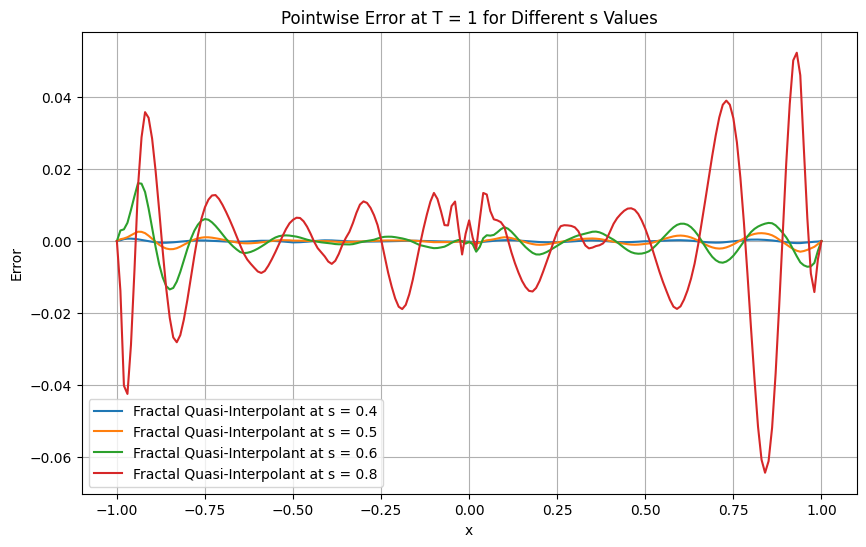

In [26]:
plt.figure(figsize=(10, 6))

for s in S:
    plt.plot(
        x,
        f_err[s],
        label=f"Fractal Quasi-Interpolant at s = {s}",
        linewidth=1.5
    )

plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Pointwise Error at T = {T} for Different s Values")
plt.grid(True)
plt.legend()

plt.savefig(f"Images/pointwise_error_T_{T}_for_s.eps", format="eps")
plt.show()

Condition Number (2-norm): 4.4070e+05
Time stepping: 100%|██████████| 100/100 [03:02<00:00,  1.83s/step]
f_Linf error for s = 0.4 is 0.000688795526938929
f_RMS error for s = 0.4 is 1.6367077544796862e-05
Condition Number (2-norm): 1.6127e+07
Time stepping: 100%|██████████| 100/100 [03:08<00:00,  1.88s/step]
f_Linf error for s = 0.5 is 0.002936421091975394
f_RMS error for s = 0.5 is 7.048237732440803e-05
Condition Number (2-norm): 5.6089e+08
Time stepping: 100%|██████████| 100/100 [03:12<00:00,  1.93s/step]
f_Linf error for s = 0.6 is 0.016070113655740514
f_RMS error for s = 0.6 is 0.00028609180762833827
Condition Number (2-norm): 5.3994e+11
Time stepping: 100%|██████████| 100/100 [03:12<00:00,  1.93s/step]
f_Linf error for s = 0.8 is 0.06425875059115171
f_RMS error for s = 0.8 is 0.0012522829773039638
Condition Number (2-norm): 1.4516e+13
Time stepping: 100%|██████████| 100/100 [03:10<00:00,  1.90s/step]
f_Linf error for s = 0.9 is 16.253667146297648
f_RMS error for s = 0.9 is 0.18570806525410172